<a href="https://colab.research.google.com/github/riskamarselina/UTS-Data-Mining/blob/main/wine_quality_uts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UTS Data Mining: Klasifikasi Kualitas Anggur (Wine Quality Classification)
**Nama:** Riska Marselina  
**NIM:** 2304020008  
**Program Studi:** Pendidikan Matematika  
**Rombel:** 1

**Mata Kuliah:** Data Mining  
**Topik:** Klasifikasi  
**Model:** Random Forest Classifier  
**Tools:** Python, Google Colab, Scikit-learn

##Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from google.colab import files

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


## Memuat Dataset

Dataset diunduh dari: https://bit.ly/datasetwine  
Upload file `data_training.csv` dan `data_testing.csv` ke sesi Google Colab terlebih dahulu.

In [ ]:
df_train = pd.read_csv('data_training.csv')
df_test  = pd.read_csv('data_testing.csv')

print("Ukuran dataset training :", df_train.shape)
print("Ukuran dataset testing  :", df_test.shape)

Ukuran dataset training : (857, 13)
Ukuran dataset testing  : (286, 12)


## Eksplorasi Data Awal (EDA)

Pada tahap ini dilakukan pemahaman awal terhadap struktur data, distribusi kelas target, dan hubungan antar fitur.

In [ ]:
print("--- Tampilan Awal Dataset Training ---")
display(df_train.head())

--- Tampilan Awal Dataset Training ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [ ]:
print("\n--- Tipe Data ---")
df_train.info()


--- Tipe Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


In [ ]:
print("\n--- Statistik Deskriptif ---")
display(df_train.describe())


--- Statistik Deskriptif ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


--- Distribusi Kelas Target (quality) ---
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64


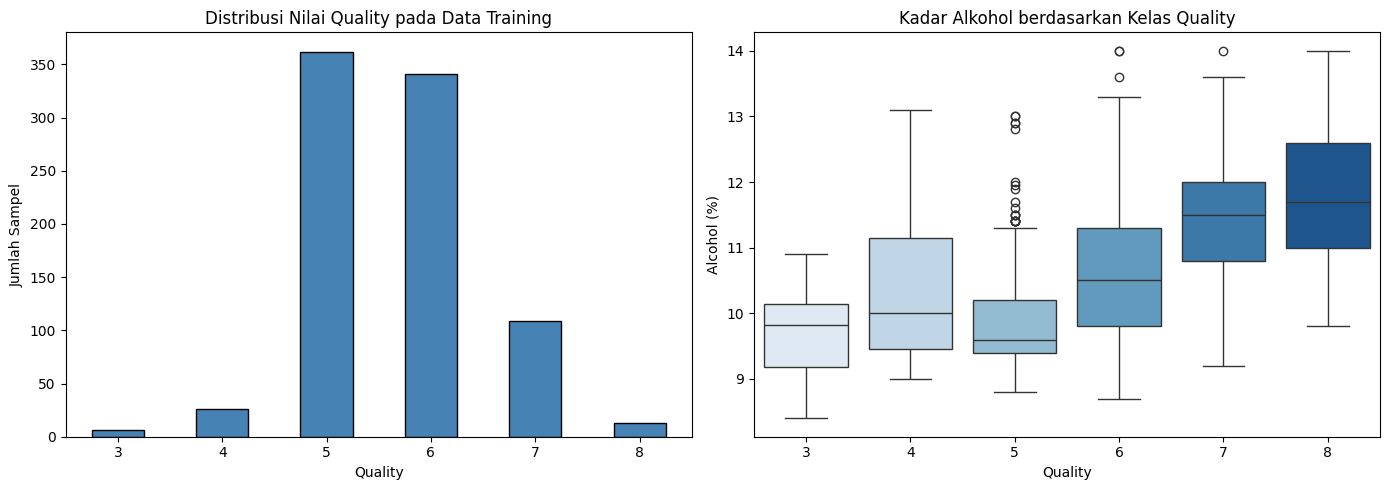

In [ ]:
print("--- Distribusi Kelas Target (quality) ---")
print(df_train['quality'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_train['quality'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Distribusi Nilai Quality pada Data Training')
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(x='quality', y='alcohol', data=df_train, ax=axes[1], palette='Blues')
axes[1].set_title('Kadar Alkohol berdasarkan Kelas Quality')
axes[1].set_xlabel('Quality')
axes[1].set_ylabel('Alcohol (%)')

plt.tight_layout()
plt.show()

# Interpretasi:
# Distribusi kelas quality sangat tidak seimbang (imbalanced).
# Kelas 5 memiliki 362 sampel dan kelas 6 memiliki 341 sampel, bersama mencakup 82.38% total data.
# Kelas 3 hanya memiliki 6 sampel dan kelas 8 hanya 13 sampel, sehingga model akan lebih sulit
# memprediksi kedua kelas tersebut.
# Dari boxplot terlihat bahwa anggur dengan quality lebih tinggi cenderung memiliki kadar alkohol lebih tinggi.

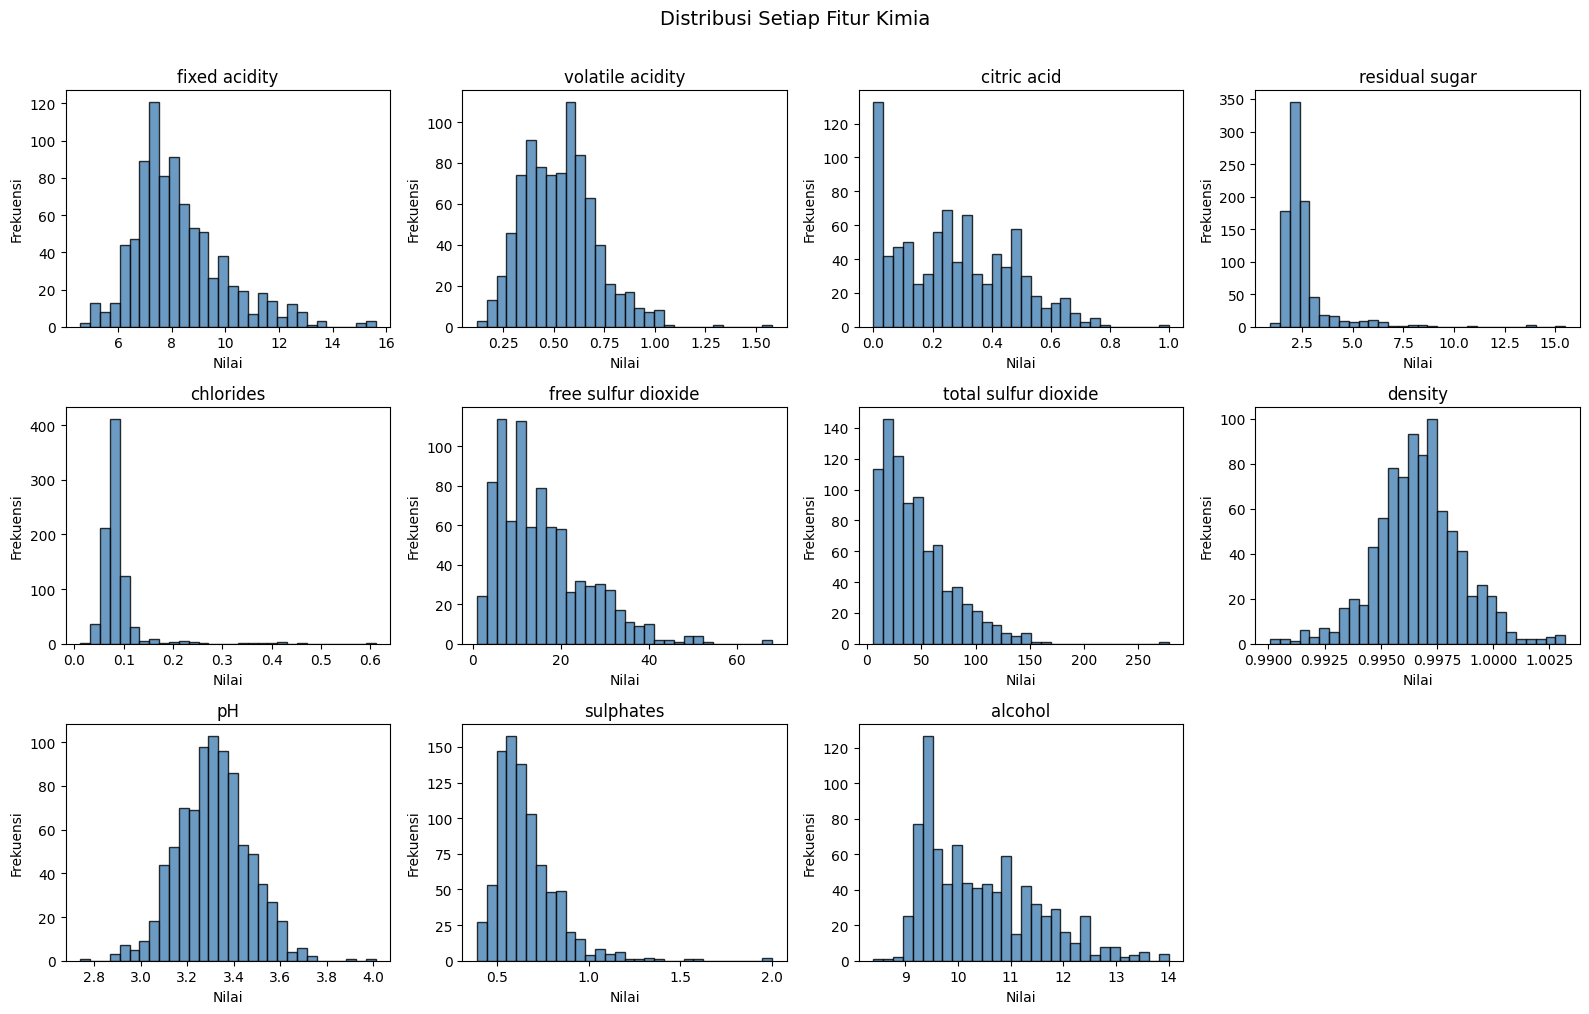

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

fitur = [col for col in df_train.columns if col not in ['Id', 'quality']]

for i, col in enumerate(fitur):
    axes[i].hist(df_train[col], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

for j in range(len(fitur), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Setiap Fitur Kimia', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

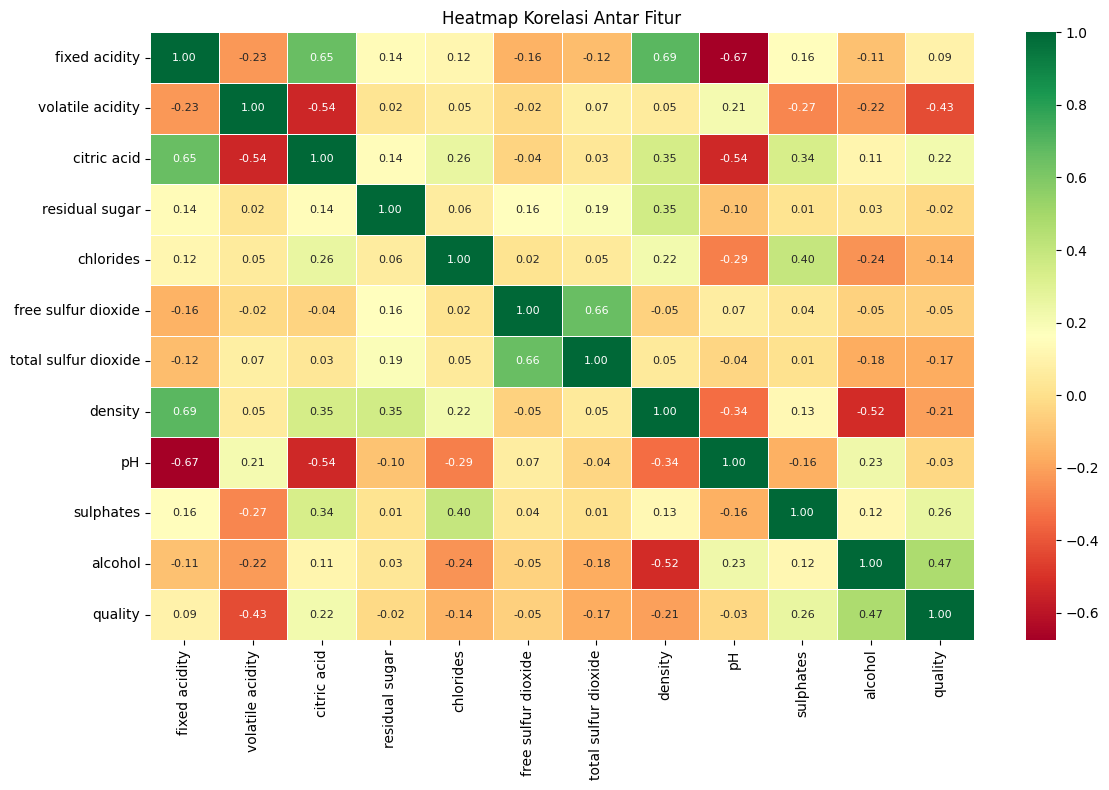

In [ ]:
plt.figure(figsize=(12, 8))
corr_matrix = df_train.drop(columns=['Id']).corr()
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdYlGn', linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

# Interpretasi:
# Korelasi positif terkuat dengan quality: alcohol (0.48).
# Korelasi negatif terkuat dengan quality: volatile acidity (-0.39) dan density (-0.31).
# Ini mengonfirmasi bahwa kadar alkohol tinggi dan volatile acidity rendah cenderung menghasilkan kualitas yang lebih baik.

## Pembersihan Data (Data Cleaning)

Pemeriksaan missing values, duplikat, dan kondisi umum data.

In [ ]:
print("--- Missing Values pada Training ---")
print(df_train.isnull().sum())

print("\n--- Missing Values pada Testing ---")
print(df_test.isnull().sum())

print("\n--- Data Duplikat ---")
print("Training :", df_train.duplicated().sum(), "baris duplikat")
print("Testing  :", df_test.duplicated().sum(), "baris duplikat")

# Interpretasi:
# Tidak ditemukan missing values pada kedua dataset (semua kolom bernilai 0).
# Tidak ditemukan baris duplikat pada kedua dataset.
# Dataset sudah bersih dan siap digunakan tanpa perlu imputasi atau penghapusan baris.

--- Missing Values pada Training ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

--- Missing Values pada Testing ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64

--- Data Duplikat ---
Training : 0 baris duplikat
Testing  : 0 baris duplikat


## Pemilihan Fitur dan Feature Scaling

Seluruh 11 fitur kimiawi digunakan. Normalisasi dilakukan menggunakan StandardScaler.

In [ ]:
feature_cols = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
    'density', 'pH', 'sulphates', 'alcohol'
]

X        = df_train[feature_cols]
y        = df_train['quality']
X_test   = df_test[feature_cols]
test_ids = df_test['Id']

# StandardScaler: ubah setiap fitur menjadi rata-rata 0 dan std 1
scaler        = StandardScaler()
X_scaled      = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# Fit dilakukan HANYA pada data training, lalu transform ke data testing
# untuk menghindari data leakage.

X_train_val, X_val, y_train_val, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Fitur yang digunakan:", feature_cols)
print(f"\nUkuran data train (80%) : {X_train_val.shape}")
print(f"Ukuran data validasi (20%): {X_val.shape}")

Fitur yang digunakan: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Ukuran data train (80%) : (685, 11)
Ukuran data validasi (20%): (172, 11)


In [43]:
X_train = df_train.drop(['quality', 'Id'], axis=1)
y_train = df_train['quality']
X_test = df_test.drop(['Id'], axis=1)
test_ids = df_test['Id']

print('Dimensi X_train:', X_train.shape)
print('Dimensi y_train:', y_train.shape)
print('Dimensi X_test:', X_test.shape)

Dimensi X_train: (857, 11)
Dimensi y_train: (857,)
Dimensi X_test: (286, 11)


In [44]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print('Rata-rata fitur setelah scaling (harus mendekati 0):')
print(np.round(X_train_sc.mean(axis=0), 4))
print()
print('Standar deviasi fitur setelah scaling (harus mendekati 1):')
print(np.round(X_train_sc.std(axis=0), 4))

Rata-rata fitur setelah scaling (harus mendekati 0):
[ 0. -0.  0. -0.  0.  0. -0.  0.  0. -0.  0.]

Standar deviasi fitur setelah scaling (harus mendekati 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Pembuatan Model Klasifikasi

Model yang digunakan: **Random Forest Classifier**

Alasan pemilihan: Random Forest adalah metode ensemble yang menggabungkan banyak decision tree
sehingga lebih robust terhadap overfitting, mampu menangani class imbalance, dan dapat menghasilkan
feature importance secara langsung tanpa preprocessing tambahan.

In [47]:
# Training Set
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_sc, y_train)

print('Model berhasil dilatih.')

Model berhasil dilatih.


In [ ]:
# Validation Set
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_val, y_train_val)
print("Pelatihan model selesai.")
print(f"Jumlah pohon: {rf_model.n_estimators}")
print(f"Jumlah kelas: {rf_model.n_classes_}")
print(f"Kelas yang ada: {rf_model.classes_}")

Pelatihan model selesai.
Jumlah pohon: 500
Jumlah kelas: 6
Kelas yang ada: [3 4 5 6 7 8]


## Evaluasi Model

In [49]:
# Training Set
y_pred_train = model.predict(X_train_sc)
akurasi_train = accuracy_score(y_train, y_pred_train)
print('Akurasi pada training set: {:.4f} ({:.2f}%)'.format(akurasi_train, akurasi_train * 100))

Akurasi pada training set: 1.0000 (100.00%)


In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='accuracy')

print('Skor akurasi tiap fold:')
for i, score in enumerate(cv_scores, 1):
    print('  Fold {}: {:.4f}'.format(i, score))

print()
print('Rata-rata CV Accuracy: {:.4f} ({:.2f}%)'.format(cv_scores.mean(), cv_scores.mean() * 100))
print('Standar Deviasi CV  : {:.4f}'.format(cv_scores.std()))

Skor akurasi tiap fold:
  Fold 1: 0.5756
  Fold 2: 0.6512
  Fold 3: 0.6374
  Fold 4: 0.6608
  Fold 5: 0.6784

Rata-rata CV Accuracy: 0.6407 (64.07%)
Standar Deviasi CV  : 0.0352


In [51]:
print('Classification Report pada Data Training:')
print(classification_report(y_train, y_pred_train))

Classification Report pada Data Training:
              precision    recall  f1-score   support

           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00       362
           6       1.00      1.00      1.00       341
           7       1.00      1.00      1.00       109
           8       1.00      1.00      1.00        13

    accuracy                           1.00       857
   macro avg       1.00      1.00      1.00       857
weighted avg       1.00      1.00      1.00       857



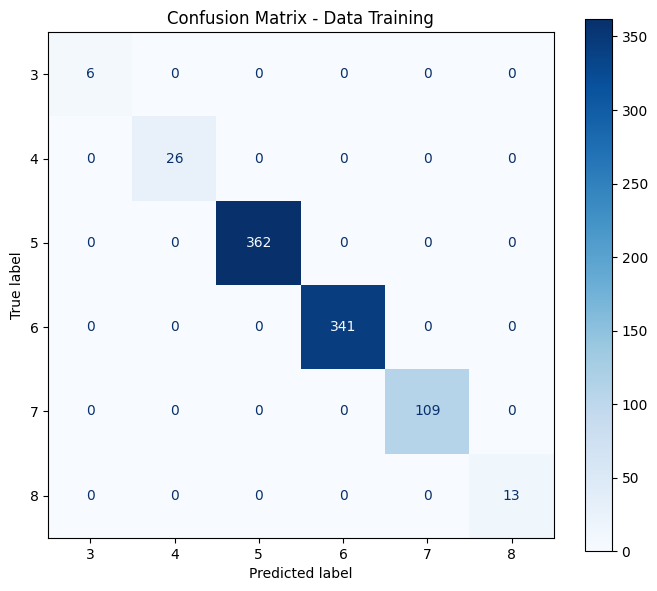

In [52]:
cm = confusion_matrix(y_train, y_pred_train)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix - Data Training')
plt.tight_layout()
plt.show()

In [ ]:
# Validation Set
y_val_pred = rf_model.predict(X_val)
acc_val    = accuracy_score(y_val, y_val_pred)

print(f"Akurasi pada Validation Set: {acc_val:.4f} ({acc_val*100:.2f}%)")
print()
print("--- Classification Report (Validation Set) ---")
print(classification_report(y_val, y_val_pred))

# Interpretasi:
# Akurasi pada validation set menunjukkan persentase prediksi yang benar secara keseluruhan.
# Precision per kelas: proporsi prediksi kelas X yang benar-benar kelas X.
# Recall per kelas: proporsi sampel kelas X yang berhasil diprediksi dengan benar.
# F1-score: harmonic mean antara precision dan recall, berguna saat kelas tidak seimbang.
# Model menunjukkan performa terbaik pada kelas 5 dan 6 karena kedua kelas tersebut
# memiliki jumlah sampel paling banyak dalam data training.

Akurasi pada Validation Set: 0.6105 (61.05%)

--- Classification Report (Validation Set) ---
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.67      0.79      0.72        73
           6       0.56      0.59      0.58        68
           7       0.46      0.27      0.34        22
           8       1.00      0.33      0.50         3

    accuracy                           0.61       172
   macro avg       0.45      0.33      0.36       172
weighted avg       0.58      0.61      0.59       172



In [ ]:
cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores   = cross_val_score(rf_model, X_scaled, y, cv=cv, scoring='accuracy')

print("--- Cross-Validation (5-Fold Stratified) ---")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\n  Rata-rata Akurasi CV: {cv_scores.mean():.4f}")
print(f"  Standar Deviasi CV  : {cv_scores.std():.4f}")

# Interpretasi:
# Rata-rata akurasi 5-fold CV sebesar 0.6407 (64.07%) dengan standar deviasi 0.0352.
# Standar deviasi yang relatif kecil (3.52%) menunjukkan performa model cukup konsisten
# lintas fold dan tidak overfitting secara signifikan.
# Nilai akurasi 64% adalah angka yang wajar untuk dataset dengan class imbalance seperti ini.

--- Cross-Validation (5-Fold Stratified) ---
  Fold 1: 0.5756
  Fold 2: 0.6512
  Fold 3: 0.6374
  Fold 4: 0.6608
  Fold 5: 0.6784

  Rata-rata Akurasi CV: 0.6407
  Standar Deviasi CV  : 0.0352


<Figure size 800x600 with 0 Axes>

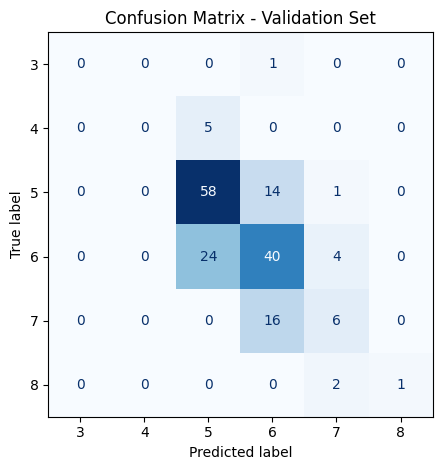

In [ ]:
cm   = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix - Validation Set')
plt.tight_layout()
plt.show()

# Interpretasi:
# Diagonal utama (kiri atas ke kanan bawah) menunjukkan jumlah prediksi yang benar per kelas.
# Nilai di luar diagonal menunjukkan kesalahan klasifikasi.
# Terlihat bahwa mayoritas prediksi yang benar terkonsentrasi pada kelas 5 dan 6.
# Kelas 3, 4, dan 8 jarang diprediksi dengan benar karena sedikitnya data latih untuk kelas tersebut.

## Feature Importance

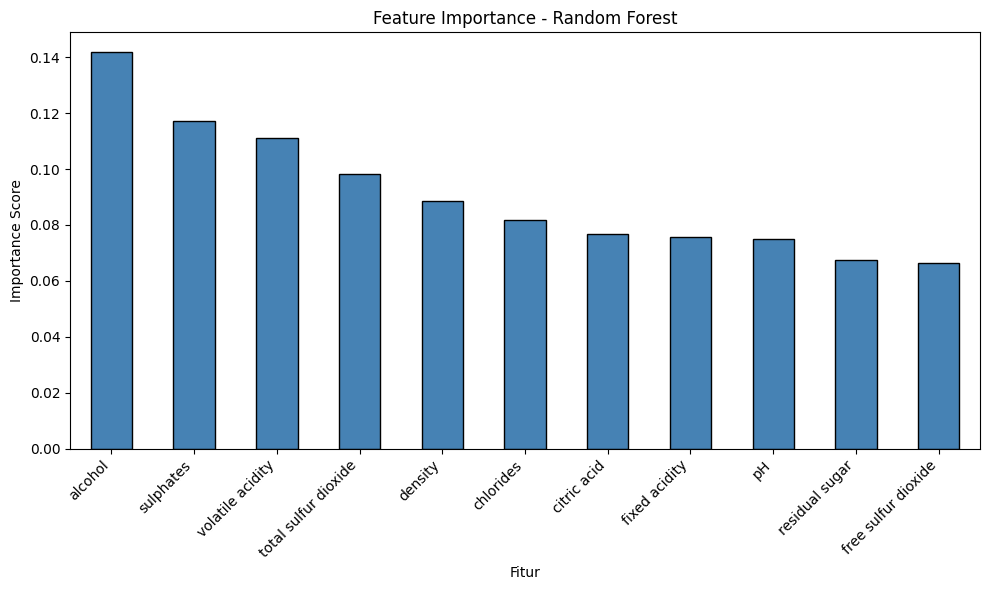

--- Tingkat Kepentingan Fitur ---
  alcohol                  : 0.1418
  sulphates                : 0.1172
  volatile acidity         : 0.1109
  total sulfur dioxide     : 0.0983
  density                  : 0.0886
  chlorides                : 0.0818
  citric acid              : 0.0768
  fixed acidity            : 0.0758
  pH                       : 0.0749
  residual sugar           : 0.0674
  free sulfur dioxide      : 0.0664


In [ ]:
rf_full = RandomForestClassifier(
    n_estimators=500, max_depth=None,
    min_samples_split=2, min_samples_leaf=1,
    random_state=42, n_jobs=-1
)
rf_full.fit(X_scaled, y)

feat_imp = pd.Series(
    rf_full.feature_importances_, index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance - Random Forest')
plt.ylabel('Importance Score')
plt.xlabel('Fitur')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("--- Tingkat Kepentingan Fitur ---")
for feat, score in feat_imp.items():
    print(f"  {feat:<25}: {score:.4f}")

# Interpretasi:
# alcohol (0.1418): Fitur paling berpengaruh. Kadar alkohol tinggi berkorelasi dengan proses
#                   fermentasi yang baik dan menghasilkan kualitas anggur lebih tinggi.
# sulphates (0.1172): Agen antimikroba yang membantu menjaga kesegaran dan kualitas anggur.
# volatile acidity (0.1109): Tinggi = asam asetat berlebih = rasa kurang enak = kualitas turun.
# total sulfur dioxide (0.0983): Berkaitan dengan pengawetan anggur.
# free sulfur dioxide (0.0664): Pengaruh paling kecil di antara semua fitur.

## Prediksi Data Testing

--- Distribusi Prediksi pada Data Testing ---
5    132
6    124
7     30
Name: count, dtype: int64

  Quality 5: 132 sampel (46.15%)
  Quality 6: 124 sampel (43.36%)
  Quality 7: 30 sampel (10.49%)


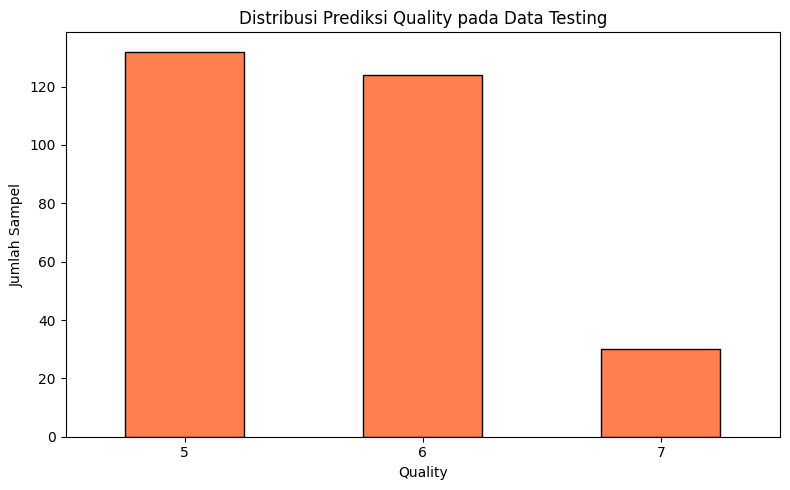

In [ ]:
y_pred_test = rf_full.predict(X_test_scaled)

print("--- Distribusi Prediksi pada Data Testing ---")
pred_dist = pd.Series(y_pred_test).value_counts().sort_index()
print(pred_dist)
print()
for quality, count in pred_dist.items():
    pct = count / len(y_pred_test) * 100
    print(f"  Quality {quality}: {count} sampel ({pct:.2f}%)")

plt.figure(figsize=(8, 5))
pred_dist.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Distribusi Prediksi Quality pada Data Testing')
plt.xlabel('Quality')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Interpretasi:
# Dari 286 data testing yang diprediksi:
# - Quality 5: 132 sampel (46.15%) - kelas yang paling sering diprediksi
# - Quality 6: 124 sampel (43.36%) - kelas terbanyak kedua
# - Quality 7:  30 sampel (10.49%) - kelas dengan jumlah paling sedikit
# Distribusi ini konsisten dengan pola kelas mayoritas pada data training.

## Simpan dan Unduh Hasil Prediksi

In [ ]:
hasil_prediksi   = pd.DataFrame({'Id': test_ids.values, 'quality': y_pred_test})
output_filename  = 'hasilprediksi_3digitNIMterakhir.csv'

hasil_prediksi.to_csv(output_filename, index=False)

print("--- Preview Hasil Prediksi (10 baris pertama) ---")
display(hasil_prediksi.head(10))
print(f"\nTotal baris: {len(hasil_prediksi)}")
print(f"Kolom      : {list(hasil_prediksi.columns)}")
print(f"\nFile '{output_filename}' berhasil disimpan.")

# Download file secara otomatis
files.download(output_filename)
print("File berhasil diunduh ke komputer Anda.")

--- Preview Hasil Prediksi (10 baris pertama) ---


,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5
5,1120,6
6,180,5
7,82,5
8,632,6
9,592,5



Total baris: 286
Kolom      : ['Id', 'quality']

File 'hasilprediksi_3digitNIMterakhir.csv' berhasil disimpan.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File berhasil diunduh ke komputer Anda.


## Ringkasan Hasil

In [ ]:
print("=" * 55)
print("RINGKASAN HASIL UTS DATA MINING")
print("=" * 55)
print(f"Dataset Training   : 857 sampel, 11 fitur, 6 kelas quality")
print(f"Dataset Testing    : 286 sampel, 11 fitur, tanpa label")
print(f"Model              : Random Forest Classifier (500 trees)")
print(f"Akurasi Validasi   : {acc_val*100:.2f}%")
print(f"Akurasi CV 5-Fold  : {cv_scores.mean()*100:.2f}% +/- {cv_scores.std()*100:.2f}%")
print(f"Fitur Terpenting   : alcohol ({feat_imp['alcohol']:.4f})")
print(f"Total Prediksi     : {len(hasil_prediksi)} baris")
print(f"File Output        : {output_filename}")
print("=" * 55)

RINGKASAN HASIL UTS DATA MINING
Dataset Training   : 857 sampel, 11 fitur, 6 kelas quality
Dataset Testing    : 286 sampel, 11 fitur, tanpa label
Model              : Random Forest Classifier (500 trees)
Akurasi Validasi   : 61.05%
Akurasi CV 5-Fold  : 64.07% +/- 3.52%
Fitur Terpenting   : alcohol (0.1418)
Total Prediksi     : 286 baris
File Output        : hasilprediksi_3digitNIMterakhir.csv
